<h5>célula no. 1</h5>
# Treinamento — Segmentação Fotovoltaica (NICFI/Planet)

Treina **UNet + ResNet50** (ou outro backbone) sobre a base TFRecord gerada pelo pipeline GEE.

**Pipeline completo:**
```
GEE  →  download_dataset_tfrecord_fotovoltaica.py  →  split_tfrecord_dataset.py
      →  <DRIVE>/train/ val/ test/ *.tfrecord.gz   →  este notebook
```

---
**Antes de começar:**  
Em `Ambiente de execução → Alterar tipo de ambiente de execução` selecione **GPU (T4)**.

<h5>célula no. 2</h5>
## 1. Autenticação e montagem do Drive

In [1]:
## célula no. 3
from google.colab import auth
auth.authenticate_user()
print('Autenticado com sucesso!')

Autenticado com sucesso!


In [2]:
## célula no. 4
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<h5>célula no. 5</h5>
## 2. Verificação de GPU

In [3]:
## célula no. 6
import tensorflow as tf
print(f'TensorFlow versão: {tf.__version__}')

# Tenta GPU, depois TPU, senão avisa
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    DEVICE = 'tpu'
    print('TPU disponível:')
    for d in tf.config.list_logical_devices('TPU'):
        print('  ', d)
except Exception:
    device_name = tf.test.gpu_device_name()
    if device_name == '/device:GPU:0':
        DEVICE = 'gpu'
        print(f'GPU encontrada em: {device_name}')
        gpus = tf.config.list_physical_devices('GPU')
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
            details = tf.config.experimental.get_device_details(g)
            print(f'  {g.name}  —  {details.get("device_name", "n/a")}')
    else:
        DEVICE = 'cpu'
        print('[AVISO] Nenhuma GPU encontrada. Treinamento será muito mais lento em CPU.')

TensorFlow versão: 2.20.0
GPU encontrada em: /device:GPU:0
  /physical_device:GPU:0  —  NVIDIA A100-SXM4-40GB


<h5>célula no. 7</h5>

## 3. Imports

In [4]:
 ## célula no. 8
import os
import sys
import glob
import datetime
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import keras
# import keras.backend as K
import keras.ops as kops

plt.style.use('ggplot')
print('Imports OK')


Imports OK


<h5>célula no. 9</h5>

## 4. Upload do segmentation_model_factory.py

Faça upload do arquivo `segmentation_model_factory.py` que está em `src/` do projeto local.

In [5]:
## célula no. 10

# Adiciona /content ao path
path_root_scripts = '/content/drive/MyDrive/DL_fotovoltaica'
sys.path.insert(0, path_root_scripts)
import importlib
import segmentation_model_factory
importlib.reload(segmentation_model_factory)

from segmentation_model_factory import (
    SegmentationModelFactory,
    SimpleDiceThreshold,
    hybrid_focal_loss,
    bce_dice_loss,
    dice_coef,
)

print('SegmentationModelFactory importada.')
print('Por favor, re-execute a célula de construção do modelo (cell_id: KAGo7p1ezCFG).')

SegmentationModelFactory importada.
Por favor, re-execute a célula de construção do modelo (cell_id: KAGo7p1ezCFG).


<h5>célula no. 11</h5>

## 5. Configurações

**Ajuste os caminhos** para onde estão seus TFRecords no Google Drive e onde quer salvar o modelo.

In [43]:
## célula no. 12
# ==============================================================================
# AJUSTE AQUI
# ==============================================================================

# Pasta raiz com subpastas train/ val/ test/ contendo os *.tfrecord.gz
DATASET_ROOT_DS = '/content/drive/MyDrive/DS_FV_tfrecords_scaled'
# DATASET_ROOT = '/content/drive/MyDrive/dsFV_PLANET_TFs'


# Pasta de saída (modelo .keras e histórico .csv)
OUTPUT_DIR   = '/content/drive/MyDrive/TRAINING_OUTPUTS_FV'

# Arquitetura
SEGMENTATION_HEAD = 'unet'      # 'unet' | 'deeplabv3plus' | 'pspnet'
# 'resnet50' | 'resnet101' | 'resnet152' | 'resnext50' | 'mobilenet' | 'xception' |
# 'efficientnetb0' | 'efficientnetb3' | 'efficientnetb7' | 'inceptionresnetv2' |
# 'inceptionresnet' | None
BACKBONE_NAME     = 'resnet101'

# Focus U-Net — atenção e perda
USE_ATTENTION = False       # True → Heavyweight Focus U-Net (canal + espacial + focal)
LOSS_NAME     = 'hybrid_focal'  # 'bce_dice' | 'hybrid_focal' (recomendada com USE_ATTENTION=True)
FOCAL_GAMMA   = 1.25        # γ do Focus Gate e da hybrid_focal_loss

# Hiperparâmetros
EPOCHS         = 250
BATCH_SIZE     = 46
LEARNING_RATE  = 1e-5
DICE_THRESHOLD = 0.85   # para o treino ao atingir este Dice na validação

# Bandas e patches
BANDS_LIST     = ['blue', 'green', 'red', 'nir', 'pvi', 'iia', 'ri', 'evi']
LABEL_KEY      = 'label'
FEATURES_KEYS  = BANDS_LIST + [LABEL_KEY]
PATCH_SIZE     = 256     # tamanho final após crop
RAW_PATCH_SIZE = 257     # saída GEE: kernel rectangle(128,128) = 257×257
INPUT_SHAPE    = (PATCH_SIZE, PATCH_SIZE, len(BANDS_LIST))  # (256, 256, 5)
NORM_FACTOR    = 10000.0 # todos os valores Int16 estão em [0, 10000]
STEPS_PER_EPOCH = 200
# Timestamp para nomear arquivos
TIMESTAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M')
ATTN_TAG  = '_focus' if USE_ATTENTION else ''

# Mapa loss_name → função
LOSS_MAP = {
    'bce_dice'    : bce_dice_loss,
    'hybrid_focal': hybrid_focal_loss,
}

# Cria pasta de saída
os.makedirs(DATASET_ROOT_DS, exist_ok=True)
reorg_dir = True

print(f'Output dir   : {DATASET_ROOT_DS}')
print(f'Arquitetura  : {SEGMENTATION_HEAD.upper()} + {BACKBONE_NAME}')
print(f'Input shape  : {INPUT_SHAPE}')
print(f'Epochs/Batch : {EPOCHS} / {BATCH_SIZE}')
print(f"TIMESTAMP    : {TIMESTAMP}")

# Verifica que as pastas do dataset existem
for split in ['train', 'val', 'test']:
    n = len(glob.glob(os.path.join(DATASET_ROOT_DS, split, '*.tfrecord.gz')))
    print(f'  [{split:5s}] {n} arquivo(s)')

Output dir   : /content/drive/MyDrive/DS_FV_tfrecords_scaled
Arquitetura  : UNET + resnet101
Input shape  : (256, 256, 8)
Epochs/Batch : 250 / 46
TIMESTAMP    : 20260502_1659
  [train] 345 arquivo(s)
  [val  ] 46 arquivo(s)
  [test ] 42 arquivo(s)


<h5>célula no. 13</h5>

## 6. Custom Losses e Métricas

In [7]:
## célula no. 14
# Losses e métricas importadas da factory (package='RemoteSensing')
# hybrid_focal_loss, bce_dice_loss, dice_coef já importados na célula de imports.

# SimpleDiceThreshold também importado da factory — não redefine localmente.

print('Losses importadas:')
print(f'  bce_dice_loss     → {bce_dice_loss.__module__}')
print(f'  hybrid_focal_loss → {hybrid_focal_loss.__module__}')
print(f'  dice_coef         → {dice_coef.__module__}')

Losses importadas:
  bce_dice_loss     → segmentation_model_factory
  hybrid_focal_loss → segmentation_model_factory
  dice_coef         → segmentation_model_factory


<h5>célula no. 15</h5>

## 7. Pipeline de Dados (TFRecord)

In [8]:
## célula no. 16
# GEE exporta neighborhoodToArray como float_list → dtype tf.float32
FEATURE_DESCRIPTION = {
    key: tf.io.FixedLenFeature([RAW_PATCH_SIZE, RAW_PATCH_SIZE], tf.float32)
    for key in FEATURES_KEYS
}

def parse_tfrecord(example_proto):
    """
      Lê exemplo e recorta 257×257 → 256×256
      (kernel rectangle(128,128) gera 257).
    """
    parsed = tf.io.parse_single_example(example_proto, FEATURE_DESCRIPTION)
    return {
        key: tf.slice(parsed[key], [0, 0], [PATCH_SIZE, PATCH_SIZE])
        for key in FEATURES_KEYS
    }


def to_model_tuple(inputs):
    """dict → (image, label). Normaliza Int16 [0,10000] → float32 [0,1]."""
    img   = tf.stack([inputs[b] for b in BANDS_LIST], axis=-1)  # (256, 256, 8)
    label = tf.expand_dims(inputs[LABEL_KEY], axis=-1)          # (256, 256, 1)
    img   = tf.cast(img,   tf.float32) / NORM_FACTOR
    label = tf.cast(label, tf.float32)
    label = tf.clip_by_value(label, 0.0, 1.0)
    return img, label


def removeNan(image, label):
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)
    label = tf.where(tf.math.is_nan(label), tf.zeros_like(label), label)
    return image, label

# Fração de patches vazios (sem nenhum painel) mantidos no treino.
# 0.25 = mantém 25% dos patches negativos; 1.0 = mantém todos.
EMPTY_PATCH_KEEP_RATE = 1.0

def filter_empty_patches(image, label):
    """
    Descarta a maioria dos patches completamente vazios (sem painel).
    Patches com pelo menos 1 pixel de painel são sempre mantidos.
    Evita que o modelo aprenda a prever fundo em tudo.
    """
    has_panel  = tf.reduce_sum(label) > 0
    keep_empty = tf.random.uniform([]) < EMPTY_PATCH_KEEP_RATE
    return tf.logical_or(has_panel, keep_empty)


# --- Augmentation ---
def augment_flip_rotate(image, label):
    """Flip H/V + rotação 90° aleatória sincronizados."""
    # label is already (256, 256, 1) from to_model_tuple, no need for tf.newaxis

    combined = tf.concat([image, label], axis=-1)
    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)
    combined = tf.image.rot90(combined, tf.random.uniform([], 0, 4, dtype=tf.int32))

    img_aug   = combined[:, :, :len(BANDS_LIST)]
    # label_aug is already (256, 256, 1), no need to squeeze
    label_aug = combined[:, :, len(BANDS_LIST):]

    return img_aug, label_aug


def augment_spatial(image, label):
    """Translação aleatória via pad+crop (±64 px)."""
    pad      = 64
    # label is already (256, 256, 1), no need for tf.newaxis
    padded_img   = tf.pad(image,    [[pad, pad], [pad, pad], [0, 0]])
    padded_label = tf.pad(label,    [[pad, pad], [pad, pad], [0, 0]])

    # Use label directly
    rx = tf.random.uniform([], 0, pad * 2 + 1, dtype=tf.int32)
    ry = tf.random.uniform([], 0, pad * 2 + 1, dtype=tf.int32)

    img_crop   = tf.slice(padded_img,   [rx, ry, 0], [PATCH_SIZE, PATCH_SIZE, len(BANDS_LIST)])
    label_crop = tf.slice(padded_label, [rx, ry, 0], [PATCH_SIZE, PATCH_SIZE, 1]) # label_crop is (256, 256, 1)

    return img_crop, label_crop # label_crop is already (256, 256, 1), no need to squeeze

def augment_radiometric(image, label):
    """Brilho, contraste e ruído gaussiano — apenas na imagem, nunca no label."""

    image = image + tf.random.uniform([], -0.10, 0.10)
    image = image * tf.random.uniform([], 0.80, 1.20)
    image = image + tf.random.normal(tf.shape(image), stddev=0.02)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

def augment_all(image, label):
    image, label = augment_flip_rotate(image, label)
    image, label = augment_spatial(image, label)
    image, label = augment_radiometric(image, label)

    return image, label


def build_dataset(split, batch_size, augment=False):
    pattern = os.path.join(DATASET_ROOT_DS, split, '*.tfrecord.gz')
    files   = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'Nenhum TFRecord em: {pattern}')
    print(f'  [{split:5s}] {len(files)} arquivo(s)')

    ds = tf.data.TFRecordDataset(files, compression_type='GZIP',
                                 num_parallel_reads=tf.data.AUTOTUNE)
    ds = ds.map(parse_tfrecord,  num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_model_tuple,  num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(removeNan,       num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_all, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.cache()  # fixa a seleção
        ds = ds.repeat()
        ds = ds.shuffle(buffer_size=1000, reshuffle_each_iteration=True)
        # ds = ds.shuffle(buffer_size=500, reshuffle_each_iteration=True)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print('Pipeline de dados definido.')


Pipeline de dados definido.


In [9]:
## célula no. 17
print(f'Construindo datasets...com BATCH_SIZE de {BATCH_SIZE}')
train_ds = build_dataset('train', BATCH_SIZE, augment=True)
val_ds   = build_dataset('val',   BATCH_SIZE, augment=False)
print('Construido datasets ok...')

Construindo datasets...com BATCH_SIZE de 46
  [train] 345 arquivo(s)
  [val  ] 46 arquivo(s)
Construido datasets ok...


<h5>célula no. 18</h5>

## 8. Visualizar amostras do dataset

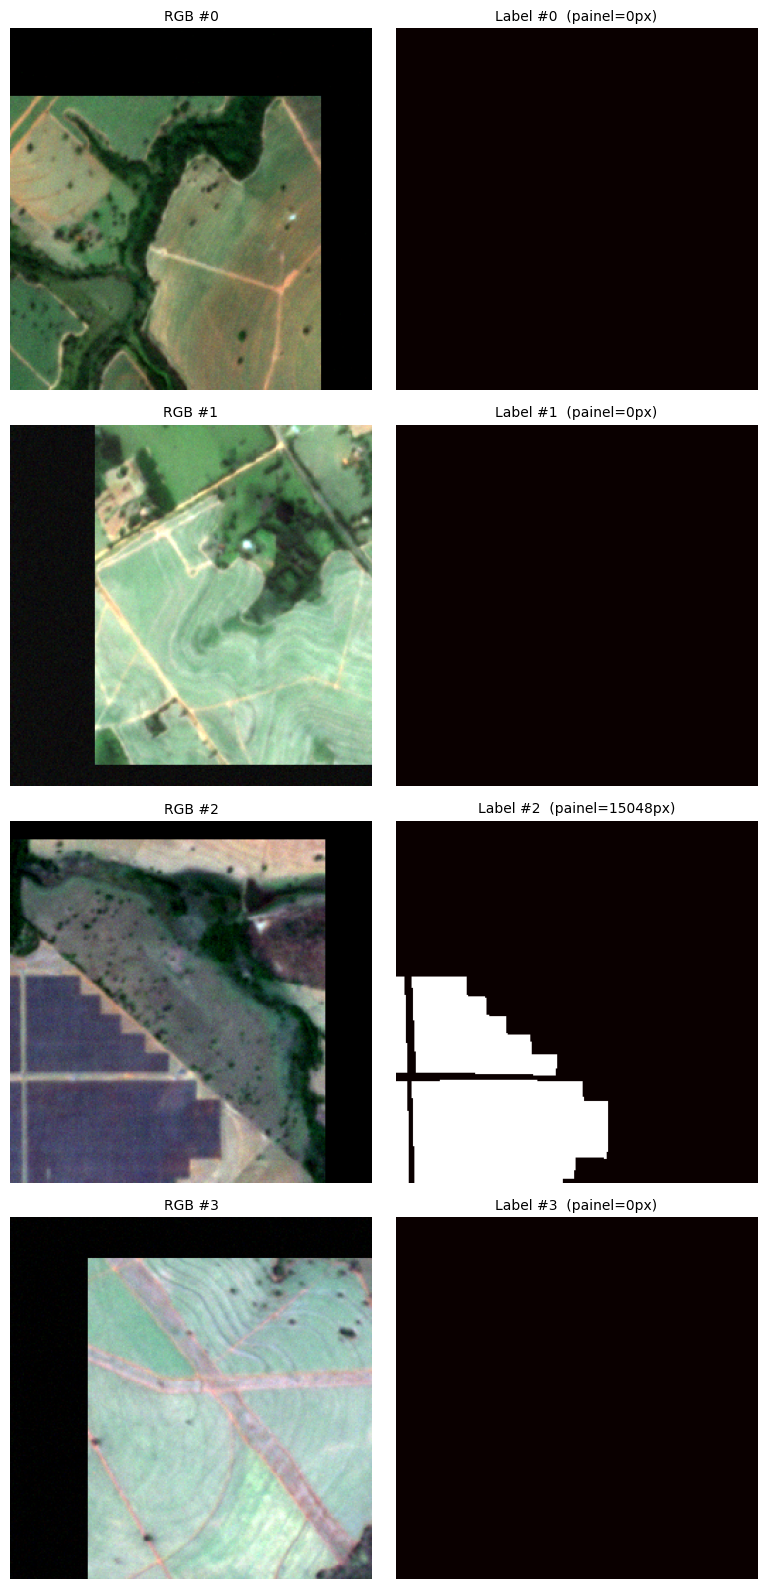

In [10]:
## célula no. 19
def convertInt16_to_Int8(arr):
    vmin, vmax = arr.min(), arr.max()
    return (((arr - vmin) / (vmax - vmin + 1e-8)) * 255).astype(np.uint8)

def show_batch(dataset, n_samples=4, saber_max=False):
    batch_img, batch_lbl = next(iter(dataset))
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 4))
    for i in range(n_samples):
        img = batch_img[i].numpy() * NORM_FACTOR  # volta para escala original
        lbl = batch_lbl[i, :, :, 0].numpy()

        r = convertInt16_to_Int8(img[:, :, 2])   # red
        g = convertInt16_to_Int8(img[:, :, 1])   # green
        b = convertInt16_to_Int8(img[:, :, 0])   # blue
        rgb = np.stack([r, g, b], axis=-1)

        axes[i, 0].imshow(rgb, vmin=0, vmax=255)
        axes[i, 0].set_title(f'RGB #{i}', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(lbl, cmap='hot', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Label #{i}  (painel={lbl.sum():.0f}px)', fontsize=10)
        axes[i, 1].axis('off')

        if saber_max:
            # Se 'img' for um tensor do TensorFlow:
            maximos = tf.reduce_max(img, axis=(0, 1)).numpy()

            # Se 'img' já for um array NumPy:
            maximos = np.max(img, axis=(0, 1))

            for i, banda in enumerate(BANDS_LIST):
                print(f"Máximo da banda {banda}: {maximos[i]:.4f}")

    plt.tight_layout()
    plt.show()


show_batch(train_ds, n_samples=4, saber_max=False)

<h5>célula no. 20</h5>

## 9. Construção do Modelo

In [44]:
## célula no. 21
print(f'Construindo: {SEGMENTATION_HEAD.upper()}{ATTN_TAG} + {BACKBONE_NAME}  |  input={INPUT_SHAPE}  loss={LOSS_NAME}  γ={FOCAL_GAMMA}')
factory = SegmentationModelFactory(
    segmentation_head= SEGMENTATION_HEAD,
    backbone_name= BACKBONE_NAME,
    input_shape= INPUT_SHAPE,
    use_attention= True,
    focal_gamma= 1.25
)
model = factory.build()
print(f'Parâmetros totais: {model.count_params():,}')

Construindo: UNET + resnet101  |  input=(256, 256, 8)  loss=hybrid_focal  γ=1.25
[Backbone] resnet101  weights=None  (8 canais)
Parâmetros totais: 34,693,829


In [45]:
## célula no. 22
model.summary(line_length=90)

Model: "focus_unet_resnet101_g1.25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)       │ (None, 256, 256, 8)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_pad                │ (None, 262, 262, 8)  │            0 │ input[0][0]           │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_conv (Conv2D)      │ (None, 128, 128, 64) │       25,152 │ conv1_pad[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_bn                 │ (None, 128, 128, 64) │          256 │ conv1_conv[0][0]      │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_relu (Activation)  │ (None, 128, 128, 64) │            0 │ conv1_bn[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ pool1_pad                │ (None, 130, 130, 64) │            0 │ conv1_relu[0][0]      │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ pool1_pool               │ (None, 64, 64, 64)   │            0 │ pool1_pad[0][0]       │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_conv      │ (None, 64, 64, 64)   │        4,160 │ pool1_pool[0][0]      │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_bn        │ (None, 64, 64, 64)   │          256 │ conv2_block1_1_conv[… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_relu      │ (None, 64, 64, 64)   │            0 │ conv2_block1_1_bn[0]… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_2_conv      │ (None, 64, 64, 64)   │       36,928 │ conv2_block1_1_relu[… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_2_bn        │ (None, 64, 64, 64)   │          256 │ conv2_block1_2_conv[… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_2_relu      │ (None, 64, 64, 64)   │            0 │ conv2_block1_2_bn[0]… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_0_conv      │ (None, 64, 64, 256)  │       16,640 │ pool1_pool[0][0]      │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_3_conv      │ (None, 64, 64, 256)  │       16,640 │ conv2_block1_2_relu[… │
│ (Conv2D)                 │                      │              │                     

 Total params: 34,693,829 (132.35 MB)

 Trainable params: 34,607,173 (132.02 MB)

 Non-trainable params: 86,656 (338.50 KB)

<h5>célula no. 23</h5>

## 11. Callbacks

In [46]:
## célula no. 24
@keras.utils.register_keras_serializable(package='Custom')
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = kops.reshape(kops.cast(y_true, 'float32'), [-1])
    y_pred_f = kops.reshape(kops.cast(y_pred, 'float32'), [-1])
    intersection = kops.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (kops.sum(y_true_f) + kops.sum(y_pred_f) + smooth)

@keras.utils.register_keras_serializable(package='Custom')
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

@keras.utils.register_keras_serializable(package='RemoteSensing')
def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=1.25, smooth=1e-6):
    """
    Focal Tversky Loss — alpha=0.3, beta=0.7 foca em Recall (reduz FN).
    Captura estruturas finas/esparsas que Dice/BCE ignoram.
    """
    y_true = kops.cast(y_true, 'float32')
    y_pred = kops.cast(y_pred, 'float32')
    y_true_f = kops.reshape(y_true, [-1])
    y_pred_f = kops.reshape(y_pred, [-1])
    tp = kops.sum(y_true_f * y_pred_f)
    fp = kops.sum((1 - y_true_f) * y_pred_f)
    fn = kops.sum(y_true_f * (1 - y_pred_f))
    tversky_index = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return kops.power((1 - tversky_index), gamma)


@keras.utils.register_keras_serializable(package='RemoteSensing')
def boundary_loss(y_true, y_pred, smooth=1e-6):
    """
    BCE concentrado nos pixels de borda do GT.
    Borda = dilatação morfológica − erosão (kernel 3×3).
    Força o modelo a ser preciso nos contornos — reduz bordas arredondadas.
    """
    y_true = kops.cast(y_true, 'float32')
    y_pred = kops.cast(y_pred, 'float32')

    # Morfologia diferenciável via max-pool 3×3
    dilated  =  tf.nn.max_pool2d( y_true, ksize=3, strides=1, padding='SAME')
    eroded   = -tf.nn.max_pool2d(-y_true, ksize=3, strides=1, padding='SAME')
    boundary = dilated - eroded   # (B, H, W, 1) — pixels exatamente na borda do GT

    # BCE pixel a pixel estável numericamente
    p   = kops.clip(y_pred, 1e-7, 1.0 - 1e-7)
    bce = -(y_true * kops.log(p) + (1 - y_true) * kops.log(1 - p))

    # Gradiente concentrado nos pixels de borda
    return kops.sum(bce * boundary) / (kops.sum(boundary) + smooth)


@keras.utils.register_keras_serializable(package='RemoteSensing')
def focal_tversky_boundary_loss(y_true, y_pred,
                                 alpha=0.3, beta=0.7, gamma=1.25,
                                 boundary_weight=0.85, smooth=1e-6):
    """
    Focal Tversky  +  Boundary Loss.
      Tversky  (peso 1.0) → captura estruturas finas, penaliza FN
      Boundary (peso 0.5) → nitidez nas bordas, penaliza erros no contorno
    Total ≈ 67 % Tversky + 33 % Boundary.
    """
    tversky  = focal_tversky_loss(y_true, y_pred, alpha=alpha, beta=beta,
                                   gamma=gamma, smooth=smooth)
    boundary = boundary_loss(y_true, y_pred, smooth=smooth)
    return tversky + boundary_weight * boundary


print('Losses e métricas definidas:')
print('  focal_tversky_loss          (alpha=0.3  beta=0.7  gamma=1.25)')
print('  boundary_loss               (kernel 3×3  morfologia diferenciável)')
print('  focal_tversky_boundary_loss (tversky + 0.5 × boundary)')

Losses e métricas definidas:
  focal_tversky_loss          (alpha=0.3  beta=0.7  gamma=1.25)
  boundary_loss               (kernel 3×3  morfologia diferenciável)
  focal_tversky_boundary_loss (tversky + 0.5 × boundary)


<h5>célula no. 25</h5>

## 10. Compilação

In [47]:
## célula no. 26
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss= focal_tversky_boundary_loss,
    metrics=[
        dice_coef,                                        # DSC (F1-Score) [cite: 375]
        keras.metrics.BinaryIoU(target_class_ids=[1],
                                threshold=0.55,
                                name='iou'),              # Intersection over Union [cite: 375]
        keras.metrics.Precision(name='precision'),        # Proporção de acertos entre os preditos [cite: 390]
        keras.metrics.Recall(name='recall')               # Proporção de pixels reais identificados [cite: 389]
    ],
)
print('Modelo compilado.')
print(f'  Optimizer : Adam  lr={LEARNING_RATE}  clipnorm=1.0')
print(f'  Loss      : bce_dice_loss')
print(f'  Metrics   : accuracy, dice_coef')

Modelo compilado.
  Optimizer : Adam  lr=1e-05  clipnorm=1.0
  Loss      : bce_dice_loss
  Metrics   : accuracy, dice_coef


<h5>célula no. 27</h5>

## 11. Callbacks

In [48]:
## célula no. 28
OUTPUT_MODEL_DIR = os.path.join(path_root_scripts, 'models_2026')
OUTPUT_MODEL_DIR

'/content/drive/MyDrive/DL_fotovoltaica/models_2026'

In [49]:
## célula no. 29
## Se está carregando o modelo desde o drive não rodar esta celda
checkpoint_path = os.path.join(
    OUTPUT_MODEL_DIR, f'best_{SEGMENTATION_HEAD}_{BACKBONE_NAME}_{TIMESTAMP}.keras'
)
log_dir = os.path.join(OUTPUT_MODEL_DIR, f'logs_{TIMESTAMP}')

# factory.get_callbacks() retorna: ModelCheckpoint + ReduceLROnPlateau +
#   EarlyStopping + SimpleDiceThreshold  — todos configurados internamente.
# TensorBoard é adicionado separadamente pois depende de log_dir local.
callbacks_list = factory.get_callbacks(
    checkpoint_path=checkpoint_path,
    dice_threshold=DICE_THRESHOLD,
) + [
    tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0),
]

print(f'Checkpoint → {checkpoint_path}')
print(f'TensorBoard→ {log_dir}')
print(f'Callbacks  : {[type(c).__name__ for c in callbacks_list]}')

Checkpoint → /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet101_20260502_1659.keras
TensorBoard→ /content/drive/MyDrive/DL_fotovoltaica/models_2026/logs_20260502_1659
Callbacks  : ['ModelCheckpoint', 'ReduceLROnPlateau', 'EarlyStopping', 'SimpleDiceThreshold', 'TensorBoard']


<h5>célula no. 30</h5>

## 12. Treinamento

In [ ]:
## célula no. 31
print(f'Iniciando treinamento  |  epochs={EPOCHS}  batch={BATCH_SIZE}  lr={LEARNING_RATE}')
print(f'Device: {DEVICE}\n')

with tf.device('/gpu:0' if DEVICE == 'gpu' else '/cpu:0'):
    resultado = model.fit(
        train_ds,
        epochs=EPOCHS,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=val_ds,
        callbacks=callbacks_list,
        verbose=1,
    )

  # Salva CSV
csv_path = os.path.join(
    OUTPUT_MODEL_DIR, f'history_{SEGMENTATION_HEAD}_{BACKBONE_NAME}_{TIMESTAMP}.csv'
)
df = pd.DataFrame(resultado.history)
df['epoch'] = df.index + 1
df.to_csv(csv_path, index=False)
print(f'Histórico salvo em: {csv_path}')
df.tail(5)

Iniciando treinamento  |  epochs=250  batch=46  lr=1e-05
Device: gpu

Epoch 1/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - dice_coef: 0.1652 - iou: 0.1171 - loss: 1.4180 - precision: 0.1129 - recall: 0.8002
Epoch 1: val_dice_coef improved from None to 0.18227, saving model to /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet101_20260502_1659.keras


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: finished saving model to /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet101_20260502_1659.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 224s 446ms/step - dice_coef: 0.1781 - iou: 0.1328 - loss: 1.3709 - precision: 0.1241 - recall: 0.8566 - val_dice_coef: 0.1823 - val_iou: 0.0443 - val_loss: 1.3220 - val_precision: 0.4656 - val_recall: 0.2509 - learning_rate: 1.0000e-05
Epoch 2/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - dice_coef: 0.2122 - iou: 0.1724 - loss: 1.2837 - precision: 0.1563 - recall: 0.9100
Epoch 2: val_dice_coef improved from 0.18227 to 0.22190, saving model to /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet101_20260502_1659.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet101_20260502_1659.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 358ms/step - dice_coef: 0.2179 - iou: 0.1796 - loss: 1.2723 - precision: 0.1637 - recall: 0.9117 - val_dice_coef: 0.2219 - val_iou: 0.1520 - val_

<h5>célula no. 32</h5>

## 13. Histórico de treinamento

<h3> Rodar a siguente Celda se o notebook foi desconectado </h3>

In [ ]:
## célula no. 33
TIMESTAMP = "20260502_1344"
csv_path = os.path.join(
    OUTPUT_MODEL_DIR, f'history_{SEGMENTATION_HEAD}_{BACKBONE_NAME}_{TIMESTAMP}.csv'
)
df = pd.read_csv(csv_path)
display(df.head())
display(df.tail())

,dice_coef,iou,loss,precision,recall,val_dice_coef,val_iou,val_loss,val_precision,val_recall,learning_rate,epoch
0,0.305603,0.264789,0.630323,0.262416,0.932204,0.047332,0.000000,1.115304,0.000000,0.000000,0.0001,1
1,0.563053,0.578915,0.379966,0.596765,0.942625,0.606171,0.577684,0.600624,0.677464,0.796246,0.0001,2
2,0.510722,0.381189,0.433089,0.405952,0.854408,0.376141,0.275545,0.625364,0.288259,0.865587,0.0001,3
3,0.494396,0.499457,0.446151,0.514807,0.935526,0.540878,0.430671,0.469268,0.446458,0.929707,0.0001,4
4,0.690848,0.724518,0.290958,0.763861,0.931159,0.070092,0.024979,1.123413,0.812942,0.026369,0.0001,5


,dice_coef,iou,loss,precision,recall,val_dice_coef,val_iou,val_loss,val_precision,val_recall,learning_rate,epoch
119,0.928252,0.907915,0.098255,0.943619,0.960036,0.913769,0.922584,0.129463,0.949836,0.969231,0.000002,120
120,0.925967,0.918603,0.104004,0.938572,0.975813,0.891923,0.848235,0.135103,0.872709,0.968846,0.000002,121
121,0.941109,0.931063,0.091707,0.956301,0.972740,0.911629,0.923860,0.129022,0.951109,0.969449,0.000002,122
122,0.929256,0.908870,0.099219,0.943995,0.960617,0.912756,0.922807,0.129712,0.948908,0.970269,0.000002,123
123,0.927048,0.919661,0.103617,0.940591,0.974980,0.891961,0.851313,0.134898,0.876546,0.968285,0.000002,124


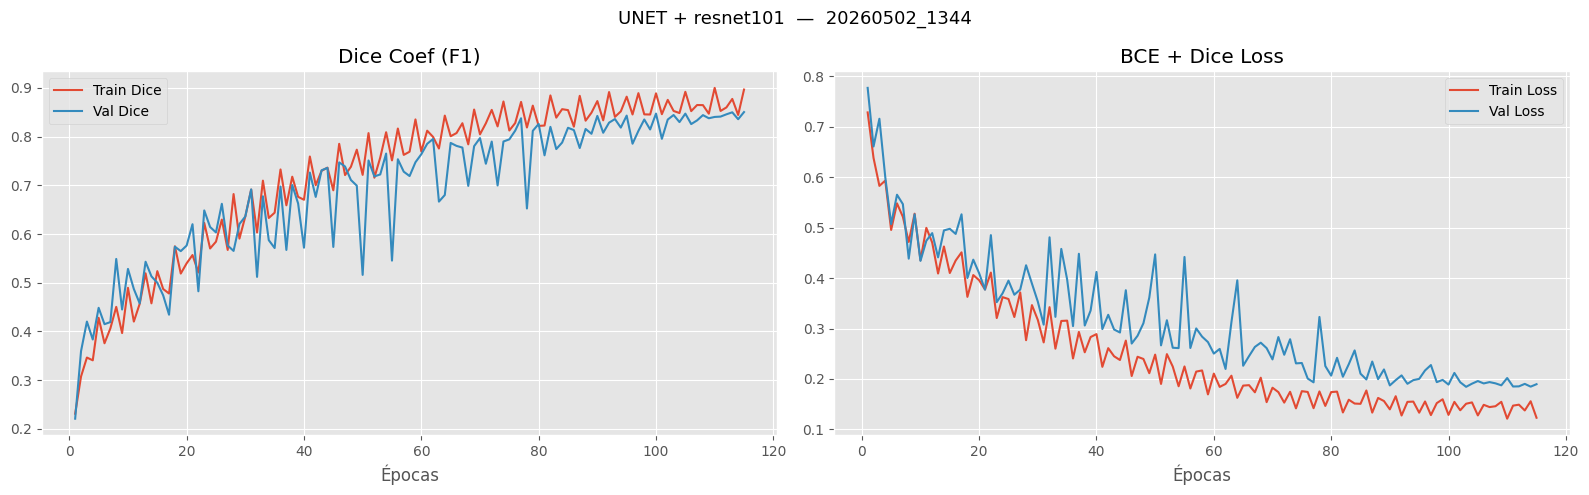

Figura salva em: /content/drive/MyDrive/TRAINING_OUTPUTS_FV/history_unet_resnet101_20260502_1344.png


In [35]:
## célula no. 34
# Plot das curvas de treinamento
epochs_range = df['epoch']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Dice Coef
axes[0].plot(epochs_range, df['dice_coef'],     label='Train Dice')
axes[0].plot(epochs_range, df['val_dice_coef'], label='Val Dice')
axes[0].set_title('Dice Coef (F1)')
axes[0].set_xlabel('Épocas')
axes[0].legend()

# Loss
axes[1].plot(epochs_range, df['loss'],     label='Train Loss')
axes[1].plot(epochs_range, df['val_loss'], label='Val Loss')
axes[1].set_title('BCE + Dice Loss')
axes[1].set_xlabel('Épocas')
axes[1].legend()

plt.suptitle(f'{SEGMENTATION_HEAD.upper()} + {BACKBONE_NAME}  —  {TIMESTAMP}', fontsize=13)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f'history_{SEGMENTATION_HEAD}_{BACKBONE_NAME}_{TIMESTAMP}.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Figura salva em: {fig_path}')

<h5>célula no. 35</h5>

## 14. Salvar modelo final

<h3> Rodar a siguente Celda se o notebook foi desconectado </h3>

In [ ]:
## célula no. 36
final_model_path = os.path.join(
    OUTPUT_MODEL_DIR, f'best_{SEGMENTATION_HEAD}_{BACKBONE_NAME}_{TIMESTAMP}.keras'
)
print("we read model from = ", final_model_path)

we read model from =  /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet50_20260429_2200.keras


In [ ]:
## célula no. 37
model.save(final_model_path)
print(f'Modelo final salvo em: {final_model_path}')
print(f'Melhor modelo (val_dice_coef) em: {checkpoint_path}')

Modelo final salvo em: /content/drive/MyDrive/TRAINING_OUTPUTS_FV/final_unet_resnet50_20260429_1436.keras
Melhor modelo (val_dice_coef) em: /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet50_20260429_1748.keras


<h5>célula no. 38</h5>

<h3> caso contrario então, rodar a siguente Celda se o notebook foi desconectado </h3>

In [ ]:
## célula no. 39
from segmentation_model_factory import ResizeLike

# Assegure-se de que as funções customizadas (loss e métricas) estejam definidas
# ou importadas antes de carregar o modelo.
# Elas foram definidas anteriormente neste notebook em CclESti3zCFE.

custom_objects = {
    'dice_coef': dice_coef, # métrica
    'focal_tversky_boundary_loss': focal_tversky_boundary_loss, # loss
    'ResizeLike': ResizeLike # Adiciona a camada customizada
}

# Carrega o modelo
loaded_model = tf.keras.models.load_model(final_model_path, custom_objects=custom_objects)

print(f'Modelo carregado com sucesso de: {final_model_path}')
loaded_model.summary()

Modelo carregado com sucesso de: /content/drive/MyDrive/DL_fotovoltaica/models_2026/best_unet_resnet50_20260429_2200.keras


Model: "focus_unet_resnet50_g1.25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input[0][0]       │
│ (ZeroPadding2D)     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │     25,152 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 46,801,233 (178.53 MB)

 Trainable params: 15,588,933 (59.47 MB)

 Non-trainable params: 34,432 (134.50 KB)

 Optimizer params: 31,177,868 (118.93 MB)

<h5>célula no. 40</h5>

## 15. (Opcional) Visualizar predições no val set

In [20]:
## célula no. 41
test_ds   = build_dataset('test',   BATCH_SIZE, augment=False)
print('Construido datasets test ok...')

  [test ] 42 arquivo(s)
Construido datasets test ok...


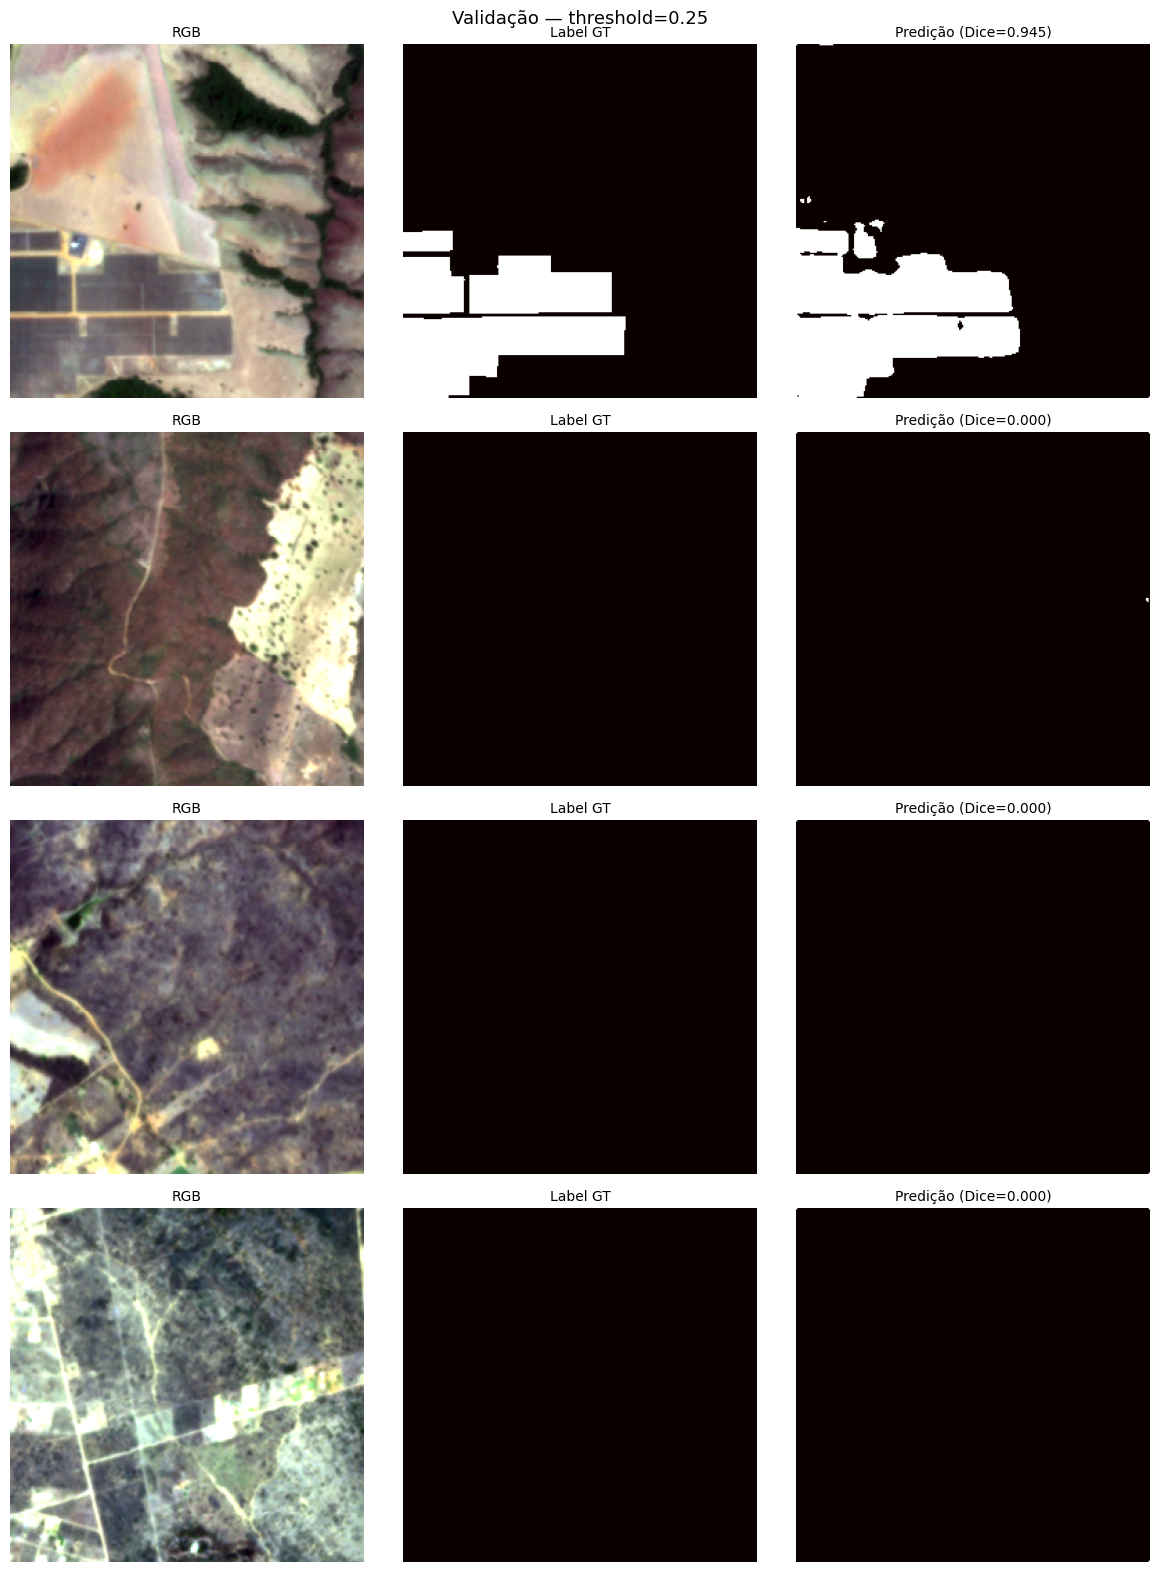

In [42]:
## célula no. 42
THRESHOLD_PRED = 0.25   # limiar para binarizar a saída sigmoid

# Para garantir um batch aleatório a cada execução da célula, embaralhe o dataset.
# O `reshuffle_each_iteration=True` assegura uma nova ordem de embaralhamento a cada iteração.
shuffled_test_ds = test_ds.shuffle(buffer_size=500, reshuffle_each_iteration=True)
batch_img, batch_lbl = next(iter(shuffled_test_ds))
preds = model.predict(batch_img, verbose=0)  # (B, 256, 256, 1)

n_show = min(4, batch_img.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 4))

for i in range(n_show):
    img = batch_img[i].numpy() * NORM_FACTOR
    lbl = batch_lbl[i, :, :, 0].numpy()
    pred = (preds[i, :, :, 0] >= THRESHOLD_PRED).astype(np.float32)

    r = convertInt16_to_Int8(img[:, :, 2])
    g = convertInt16_to_Int8(img[:, :, 1])
    b = convertInt16_to_Int8(img[:, :, 0])
    rgb = np.stack([r, g, b], axis=-1)

    axes[i, 0].imshow(rgb, vmin=0, vmax=255)
    axes[i, 0].set_title('RGB', fontsize=10); axes[i, 0].axis('off')

    axes[i, 1].imshow(lbl, cmap='hot', vmin=0, vmax=1)
    axes[i, 1].set_title('Label GT', fontsize=10); axes[i, 1].axis('off')

    axes[i, 2].imshow(pred, cmap='hot', vmin=0, vmax=1)
    dice_val = (2 * (lbl * pred).sum()) / (lbl.sum() + pred.sum() + 1e-6)
    axes[i, 2].set_title(f'Predição (Dice={dice_val:.3f})', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle(f'Validação — threshold={THRESHOLD_PRED}', fontsize=13)
plt.tight_layout()
plt.show()